# Inference Recorder Review
This notebook is focused on visually checking what the inference recorder is saving.
It is intentionally exploratory and tolerant to partial runs.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebooks.review_utils import (
    PROJECT_ROOT,
    discover_recorder_payloads,
    list_recorder_files,
    extract_decoder_deformable_attention,
    load_recorder_payload,
    resolve_image_bank_path,
    payload_summary_frame,
    activation_inventory_frame,
    decoder_attention_summary_frame,
    compute_decoder_attention_query_profiles,
    plot_scanpath_overview,
    plot_attention_heatmap,
    plot_sampling_locations,
    plot_decoder_deformable_attention_overlay,
    plot_decoder_attention_query_profiles,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)
PROJECT_ROOT

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath')

In [2]:
all_pt_files = list_recorder_files()
display(all_pt_files.head(20))

recorder_files = discover_recorder_payloads(limit=50)
display(recorder_files)

if recorder_files.empty:
    print('No inference-recorder payloads were found yet. Once a run produces *.pt payloads, re-run this notebook.')

,file,modified,size_kb
0,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0020_batch_00164_step_003299_Fixation.pt,2026-03-17 10:21:18.139412403,10222.6
1,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0135_batch_00054_Combined.pt,2026-03-17 10:21:18.042153597,7670.1
2,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0055_batch_00164_step_009074_Combined.pt,2026-03-17 10:21:17.966344118,10951.3
3,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0135_batch_00164_step_022274_Combined.pt,2026-03-17 10:21:17.860257626,10469.6
4,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0100_batch_00054_Combined.pt,2026-03-17 10:21:17.760137081,7670.1
5,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0120_batch_00164_step_019799_Combined.pt,2026-03-17 10:21:17.683246136,10710.4
6,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0020_batch_00054_Fixation.pt,2026-03-17 10:21:17.583017349,7668.3
7,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0130_batch_00054_Combined.pt,2026-03-17 10:21:17.503085852,7670.1
8,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0065_batch_00054_Combined.pt,2026-03-17 10:21:17.423606157,6860.6
9,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0100_batch_00164_step_016499_Combined.pt,2026-03-17 10:21:17.355309725,10951.3


,file,split,phase,epoch,batch_index,global_step,modified,size_kb
0,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0020_batch_00164_step_003299_Fixation.pt,train,Fixation,20,164,3299.0,2026-03-17 10:21:18.139412403,10222.6
1,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0135_batch_00054_Combined.pt,val,Combined,135,54,NaN,2026-03-17 10:21:18.042153597,7670.1
2,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0055_batch_00164_step_009074_Combined.pt,train,Combined,55,164,9074.0,2026-03-17 10:21:17.966344118,10951.3
3,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0135_batch_00164_step_022274_Combined.pt,train,Combined,135,164,22274.0,2026-03-17 10:21:17.860257626,10469.6
4,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0100_batch_00054_Combined.pt,val,Combined,100,54,NaN,2026-03-17 10:21:17.760137081,7670.1
5,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0120_batch_00164_step_019799_Combined.pt,train,Combined,120,164,19799.0,2026-03-17 10:21:17.683246136,10710.4
6,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0020_batch_00054_Fixation.pt,val,Fixation,20,54,NaN,2026-03-17 10:21:17.583017349,7668.3
7,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0130_batch_00054_Combined.pt,val,Combined,130,54,NaN,2026-03-17 10:21:17.503085852,7670.1
8,outputs\outputs\2026-03-16\18-24-45\inference_records\val_epoch_0065_batch_00054_Combined.pt,val,Combined,65,54,NaN,2026-03-17 10:21:17.423606157,6860.6
9,outputs\outputs\2026-03-16\18-24-45\inference_records\train_epoch_0100_batch_00164_step_016499_Combined.pt,train,Combined,100,164,16499.0,2026-03-17 10:21:17.355309725,10951.3


In [3]:
selected_path = None
if not recorder_files.empty:
    selected_path = PROJECT_ROOT / recorder_files.iloc[0]['file']
selected_path

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath/outputs/outputs/2026-03-16/18-24-45/inference_records/train_epoch_0020_batch_00164_step_003299_Fixation.pt')

## Decoder Deformable Attention Overlay
This section is focused on `decoder.#.second_cross_attn` only.
The origin is reconstructed from teacher-forced fixation coordinates, so query `0` starts at `(0.5, 0.5)` and later queries start at the previous ground-truth fixation.
The `eye_decoder.#.cross_attn` branch is intentionally left out for this iteration.

In [4]:
external_record_dir = Path(r'C:\Users\ulloa\Miooooo\Master\thesis\projectes\From-Noisy-Eye-Tracking-To-Scanpath\outputs\outputs\2026-03-16\18-24-45\inference_records')
external_candidates = sorted(external_record_dir.glob('*.pt')) if external_record_dir.exists() else []
payload_path = external_candidates[-4] if external_candidates else selected_path
sample_index = 1
decoder_layer = 3
query_index = 8
aggregate_heads = False
head_index = None
image_bank_path = None

payload_path

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath/outputs/outputs/2026-03-16/18-24-45/inference_records/val_epoch_0125_batch_00054_Combined.pt')

In [5]:
payload = None
if payload_path is not None:
    payload = load_recorder_payload(payload_path)
    display(payload.get('metadata', {}))
    display(payload_summary_frame(payload))
    try:
        resolved_image_bank_path = resolve_image_bank_path(payload_path=payload_path, image_bank_path=image_bank_path)
        print('image_bank_path =', resolved_image_bank_path)
    except FileNotFoundError as exc:
        resolved_image_bank_path = None
        print(exc)

{'epoch': 125,
 'phase': 'Combined',
 'split': 'val',
 'batch_index': 54,
 'global_step': None,
 'model_name': 'MixerModel'}

,section,name,shape,dtype
0,data,sample_idx,"(15,)",torch.int64
1,data,image_idx,"(15,)",torch.int64
2,data,eye_tracking_input,"(15, 13, 3)",torch.float32
3,data,fixation_ground_truth,"(15, 12, 3)",torch.float32
4,outputs,denoise_output,"(15, 13, 2)",torch.float32
5,outputs,scanpath_coordinates,"(15, 13, 2)",torch.float32
6,outputs,scanpath_duration,"(15, 13, 1)",torch.float32
7,outputs,scanpath_end_logits,"(15, 13, 1)",torch.float32
8,activations,eye_decoder.0.cross_attn.sampling_offsets,"(15, 13, 8, 4, 2)",list
9,activations,eye_decoder.0.cross_attn.attention_weights,"(15, 13, 8, 4)",list


image_bank_path = C:\Users\ulloa\Miooooo\Master\thesis\projectes\From-Noisy-Eye-Tracking-To-Scanpath\data\Coco FreeView\all_images_256.pth


In [6]:
for key, values in (list(payload["activations"].values())[-1]).items():
    print(key, type(values))

sampling_offsets <class 'list'>
attention_weights <class 'list'>
sampling_locations <class 'list'>


In [7]:
len((list(list(payload["activations"].values())[-1].values())[0]))

13

In [8]:
decoder_attention_info = None
if payload is not None:
    decoder_attention_info = extract_decoder_deformable_attention(
        payload,
        sample_index=sample_index,
        decoder_layer=decoder_layer,
        query_index=query_index,
        aggregate_heads=aggregate_heads,
        head_index=head_index,
    )
    display({
        'module_name': decoder_attention_info['module_name'],
        'query_count': decoder_attention_info['query_count'],
        'num_heads': decoder_attention_info['num_heads'],
        'num_points': decoder_attention_info['num_points'],
        'valid_fixation_count': decoder_attention_info['valid_fixation_count'],
        'is_terminal_or_padded': decoder_attention_info['is_terminal_or_padded'],
        'selected_head_index': decoder_attention_info['selected_head_index'],
    })
    display(decoder_attention_summary_frame(
        payload,
        sample_index=sample_index,
        decoder_layer=decoder_layer,
        query_index=query_index,
        aggregate_heads=aggregate_heads,
        head_index=head_index,
    ))

{'module_name': 'decoder.3.second_cross_attn',
 'query_count': 13,
 'num_heads': 8,
 'num_points': 4,
 'valid_fixation_count': 8,
 'is_terminal_or_padded': True,
 'selected_head_index': None}

,label,target_x,target_y,delta_x,delta_y,attention_weight
0,head_0_point_0,0.485026,0.297026,0.097704,0.000074,0.224066
1,head_0_point_1,0.485485,0.280002,0.098163,-0.016950,0.222922
2,head_0_point_2,0.423965,0.316002,0.036644,0.019050,0.212267
3,head_0_point_3,2.040103,-0.272870,1.652781,-0.569822,0.340745
4,head_1_point_0,0.414549,0.384747,0.027227,0.087795,0.527051
5,head_1_point_1,0.440604,0.385571,0.053282,0.088618,0.032095
6,head_1_point_2,1.139469,0.953782,0.752148,0.656830,0.038822
7,head_1_point_3,0.919007,1.635670,0.531686,1.338718,0.402032
8,head_2_point_0,0.541560,0.560758,0.154239,0.263806,0.228419
9,head_2_point_1,0.552942,0.563130,0.165620,0.266177,0.155106


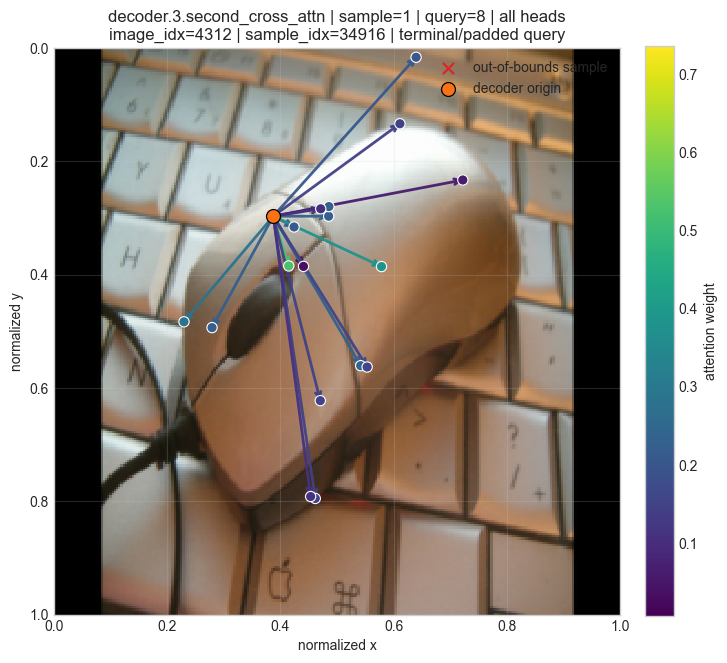

In [9]:
if payload is not None:
    plot_decoder_deformable_attention_overlay(
        payload,
        sample_index=sample_index,
        decoder_layer=decoder_layer,
        query_index=query_index,
        aggregate_heads=aggregate_heads,
        head_index=head_index,
        payload_path=payload_path,
        image_bank_path=image_bank_path,
    )

query count: (15, 13, 8, 4, 2)
attention shape (13, 8, 4)
query count: (15, 13, 8, 4, 2)
attention shape (13, 8, 4)
query count: (15, 13, 8, 4, 2)
attention shape (13, 8, 4)
query count: (15, 13, 8, 4, 2)
attention shape (13, 8, 4)


,module_name,decoder_layer,query_index,in_bounds_attention_mass,distance_to_current_point,distance_to_next_point,distance_to_previous_point,valid_fixation_count,is_valid_query
0,decoder.0.second_cross_attn,0,0,0.051933,0.423615,0.459389,NaN,8,True
1,decoder.0.second_cross_attn,0,1,0.102507,0.415237,0.555170,0.314211,8,True
2,decoder.0.second_cross_attn,0,2,0.082248,0.457608,0.567026,0.318942,8,True
3,decoder.0.second_cross_attn,0,3,0.076477,0.438632,0.345899,0.453447,8,True
4,decoder.0.second_cross_attn,0,4,0.113573,0.361292,0.482370,0.321466,8,True
5,decoder.0.second_cross_attn,0,5,0.073943,0.487645,0.505977,0.432481,8,True
6,decoder.0.second_cross_attn,0,6,0.061921,0.389475,0.376111,0.379165,8,True
7,decoder.0.second_cross_attn,0,7,0.059263,0.291984,0.302285,0.514673,8,True
8,decoder.0.second_cross_attn,0,8,0.053401,0.301559,NaN,0.291649,8,False
9,decoder.0.second_cross_attn,0,9,0.067760,NaN,NaN,0.304574,8,False


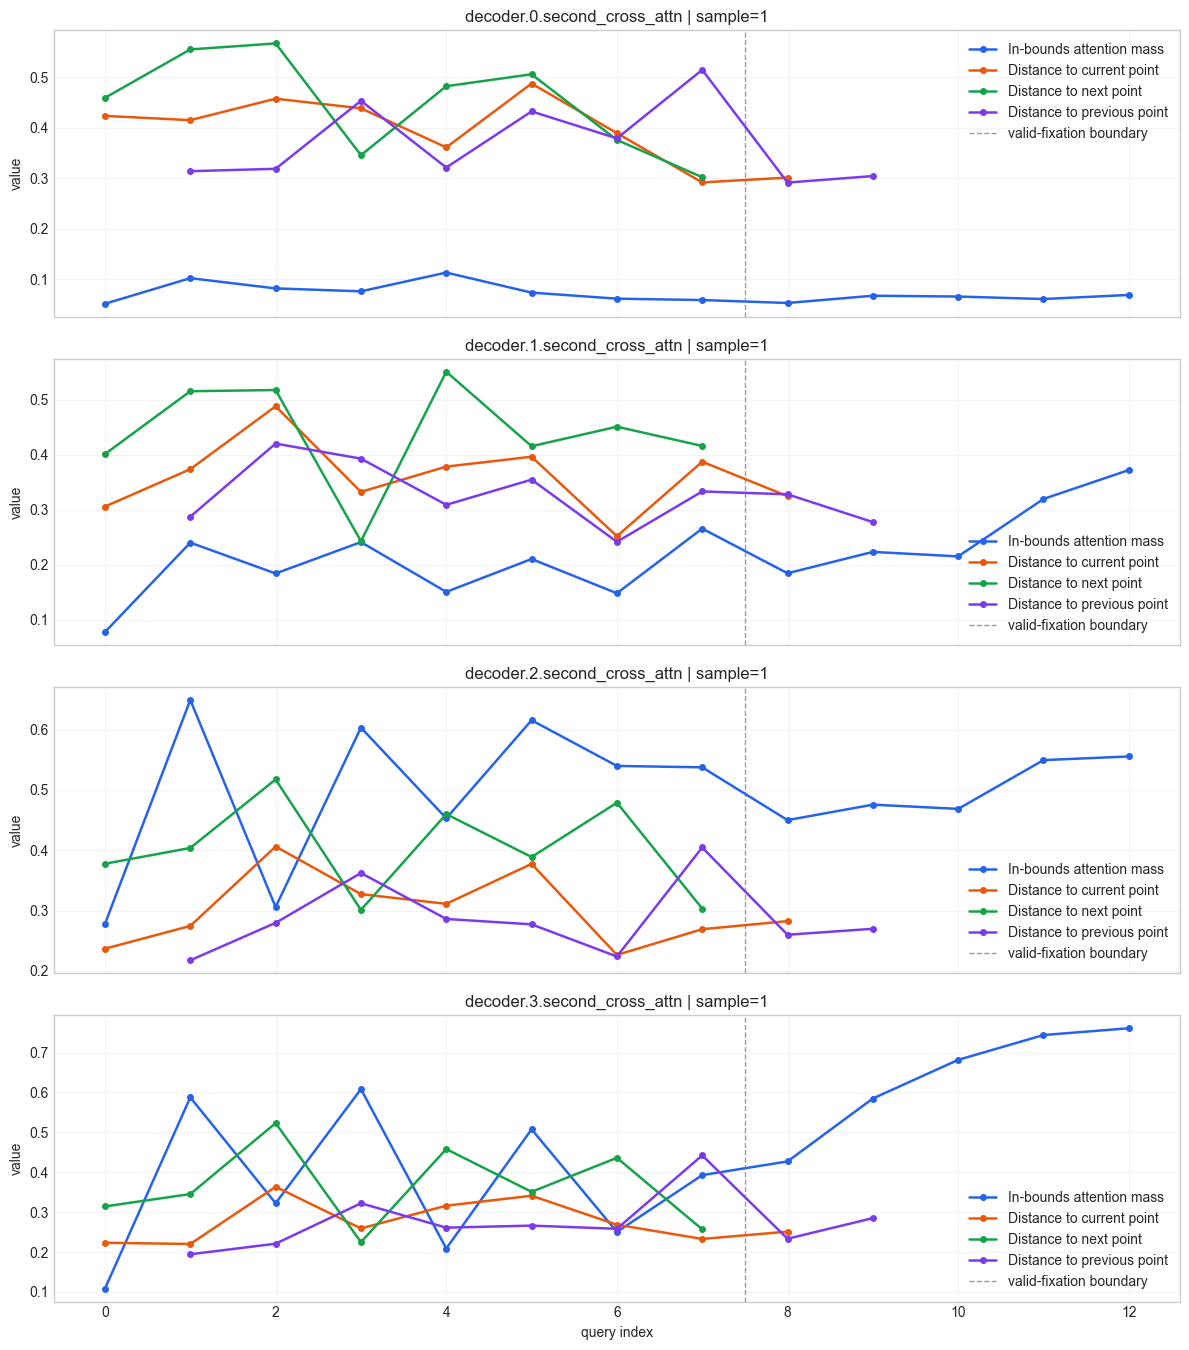

In [10]:
if payload is not None:
    decoder_query_profiles = plot_decoder_attention_query_profiles(
        payload,
        sample_index=sample_index,
    )
    display(decoder_query_profiles)


In [11]:
if payload is not None:
    display(activation_inventory_frame(payload).sort_values(['module', 'activation']).reset_index(drop=True))

,module,activation,shape,captures
0,decoder.0.first_cross_attn,attention_weights,"(15, 8, 1, 13)",13
1,decoder.0.second_cross_attn,attention_weights,"(15, 1, 8, 4)",13
2,decoder.0.second_cross_attn,sampling_locations,"(15, 1, 8, 4, 2)",13
3,decoder.0.second_cross_attn,sampling_offsets,"(15, 1, 8, 4, 2)",13
4,decoder.1.first_cross_attn,attention_weights,"(15, 8, 1, 13)",13
5,decoder.1.second_cross_attn,attention_weights,"(15, 1, 8, 4)",13
6,decoder.1.second_cross_attn,sampling_locations,"(15, 1, 8, 4, 2)",13
7,decoder.1.second_cross_attn,sampling_offsets,"(15, 1, 8, 4, 2)",13
8,decoder.2.first_cross_attn,attention_weights,"(15, 8, 1, 13)",13
9,decoder.2.second_cross_attn,attention_weights,"(15, 1, 8, 4)",13


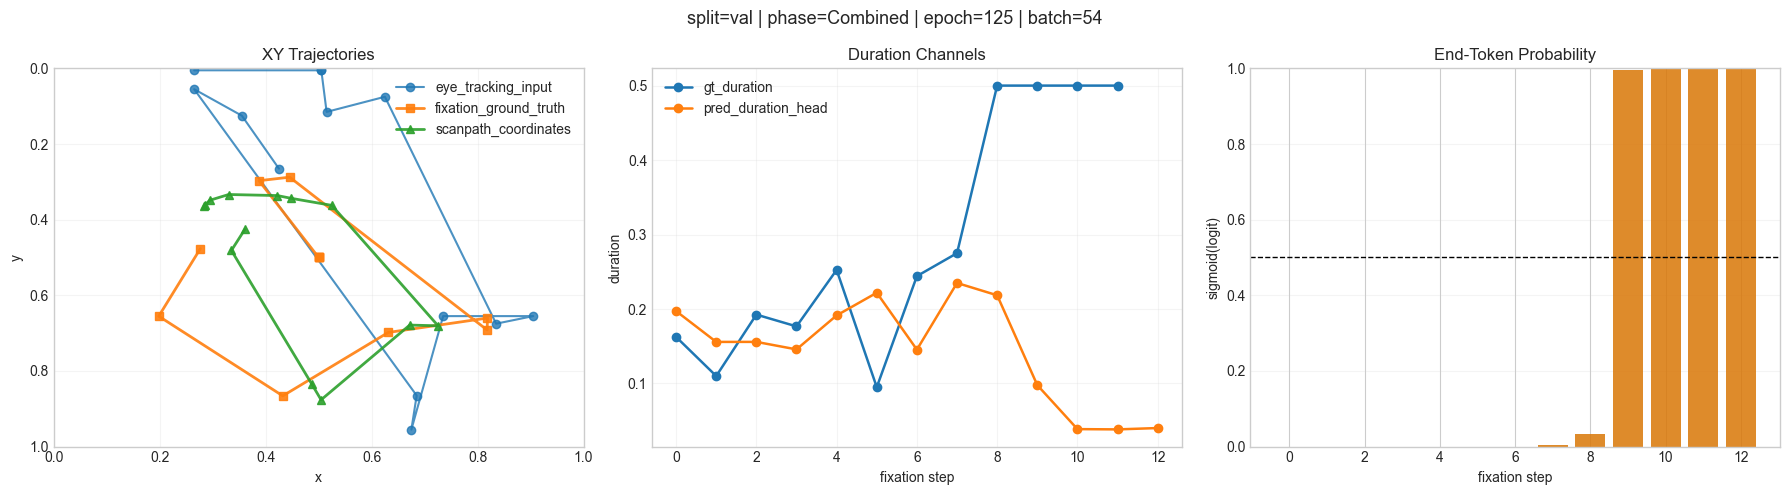

In [12]:
if payload is not None:
    plot_scanpath_overview(payload, sample_index=sample_index)

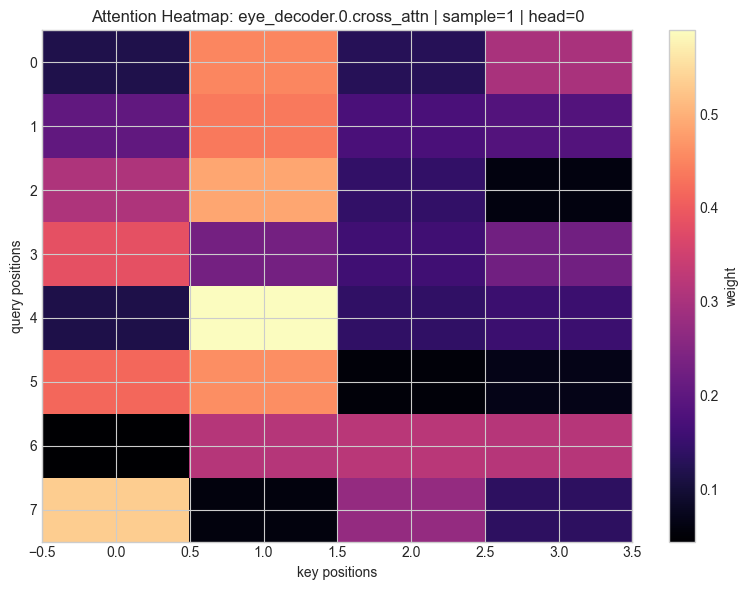

In [13]:
if payload is not None:
    try:
        plot_attention_heatmap(payload, sample_index=sample_index, head_index=0)
    except ValueError as exc:
        print(exc)

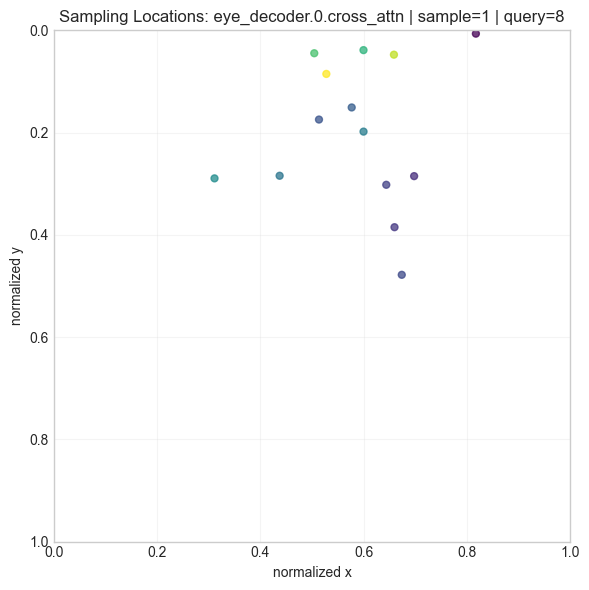

In [14]:
if payload is not None:
    try:
        plot_sampling_locations(payload, sample_index=sample_index, query_index=query_index)
    except ValueError as exc:
        print(exc)

## Notes
- `data` comes from `InferenceRecorder.record_batch` and currently includes indices plus input/target tensors when present.
- `outputs` includes `denoise`, `coord`, `dur`, `reg`, and `cls` under more descriptive names.
- `activations` currently come from attention modules in `blocks.py`, mainly cross-attention weights and deformable-attention sampling tensors.